# Marketing Campaign Analysis

## Objective
The goal of this project is to analyze marketing campaign performance and identify which channels and campaigns generate the highest return on investment (ROI).

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('marketing_campaign_dataset.csv')
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


###Explaination
We load the dataset to understand its structure, columns, and sample data.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [47]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


###Explaination
- df.info() shows data types and missing values
- df.describe() provides statistical summary of numerical columns

In [48]:
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [49]:
df['Acquisition_Cost'].head()

,Acquisition_Cost
0,16174.0
1,11566.0
2,10200.0
3,12724.0
4,16452.0


In [50]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Duration          200000 non-null  object        
 5   Channel_Used      200000 non-null  object        
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  object        
 10  Language          200000 non-null  object        
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Cust

In [52]:
df['CTR'] = df['Clicks'] / df['Impressions']

In [53]:
df[['Clicks','Impressions','CTR']].head()

,Clicks,Impressions,CTR
0,506,1922,0.263267
1,116,7523,0.015419
2,584,7698,0.075864
3,217,1820,0.119231
4,379,4201,0.090217


##Analysis

In [54]:
channel_roi = df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)
channel_roi

,ROI
Channel_Used,
Facebook,5.018699
Website,5.014167
Google Ads,5.003141
Email,4.996487
YouTube,4.993754
Instagram,4.988706


In [55]:
df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)

,ROI
Campaign_Type,
Influencer,5.011068
Search,5.008357
Display,5.006551
Email,4.994295
Social Media,4.991784


In [56]:
df.groupby('Customer_Segment')['Conversion_Rate'].mean().sort_values(ascending=False)

,Conversion_Rate
Customer_Segment,
Foodies,0.080257
Outdoor Adventurers,0.080180
Tech Enthusiasts,0.080168
Health & Wellness,0.079945
Fashionistas,0.079794


In [57]:
df.sort_values(by='ROI', ascending=False).head(10)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,CTR
65640,65641,Alpha Innovations,Search,Women 25-34,15 days,Website,0.09,18624.0,8.0,Miami,German,135,8364,9,Foodies,2021-11-02,0.016141
143790,143791,Alpha Innovations,Influencer,Men 18-24,60 days,Website,0.06,17371.0,8.0,Los Angeles,English,290,3637,3,Foodies,2021-12-12,0.079736
143503,143504,Innovate Industries,Influencer,Women 35-44,30 days,YouTube,0.04,5889.0,8.0,New York,French,660,4459,5,Fashionistas,2021-02-28,0.148015
121639,121640,TechCorp,Influencer,Men 18-24,15 days,Google Ads,0.14,7081.0,8.0,Chicago,French,350,1682,7,Fashionistas,2021-04-05,0.208086
120917,120918,TechCorp,Social Media,Men 18-24,45 days,Website,0.11,6677.0,8.0,Miami,German,465,2766,9,Foodies,2021-04-13,0.168113
73364,73365,Innovate Industries,Display,Men 25-34,15 days,Website,0.15,5277.0,8.0,New York,Spanish,511,6270,5,Foodies,2021-12-31,0.081499
48870,48871,TechCorp,Display,Men 25-34,15 days,Website,0.12,6670.0,8.0,Miami,English,754,9802,10,Foodies,2021-11-22,0.076923
42868,42869,DataTech Solutions,Display,Women 35-44,60 days,Website,0.01,5659.0,8.0,Chicago,Spanish,724,3588,8,Tech Enthusiasts,2021-06-13,0.201784
42999,43000,NexGen Systems,Email,All Ages,45 days,Google Ads,0.09,12833.0,8.0,Chicago,Mandarin,870,7386,4,Outdoor Adventurers,2021-10-22,0.117790
83445,83446,Alpha Innovations,Search,Women 35-44,15 days,Email,0.04,18956.0,8.0,Houston,English,743,8741,2,Foodies,2021-08-14,0.085002


##Visualization


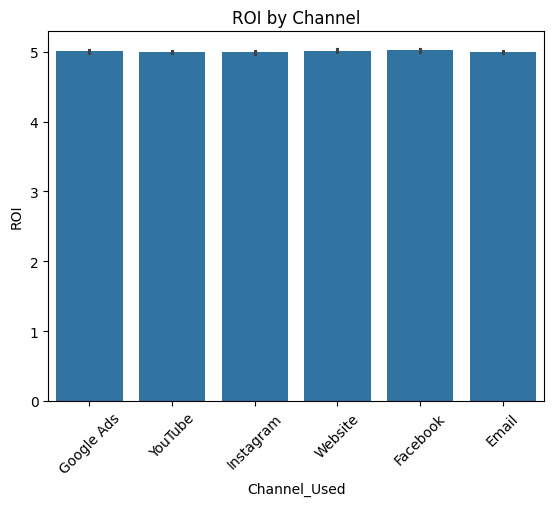

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Channel_Used', y='ROI', data=df)
plt.xticks(rotation=45)
plt.title("ROI by Channel")
plt.show()

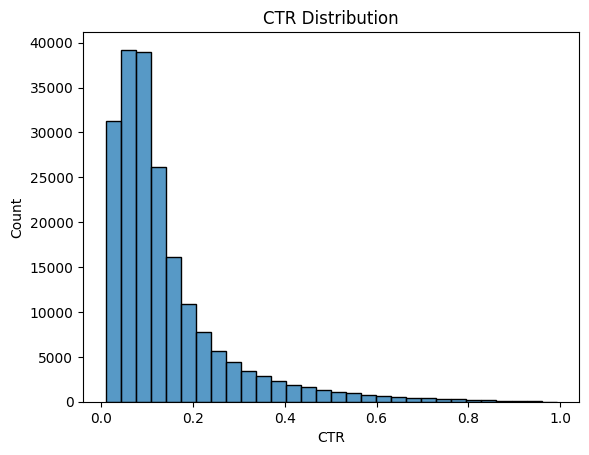

In [59]:
sns.histplot(df['CTR'], bins=30)
plt.title("CTR Distribution")
plt.show()

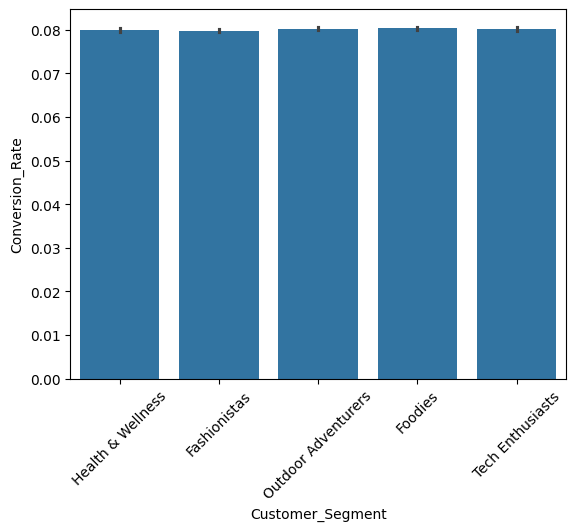

In [60]:
sns.barplot(x='Customer_Segment', y='Conversion_Rate', data=df)
plt.xticks(rotation=45)
plt.show()

##Advanced Analysis

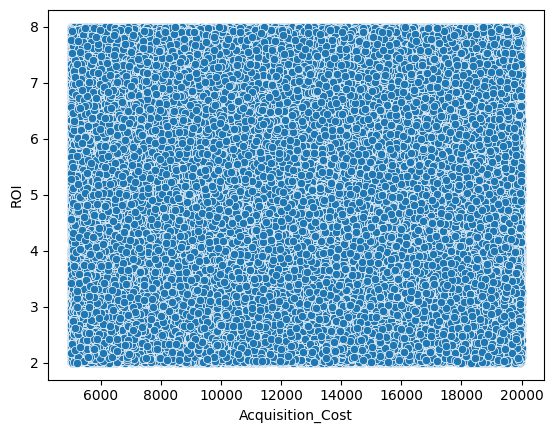

In [61]:
sns.scatterplot(x='Acquisition_Cost', y='ROI', data=df)
plt.show()

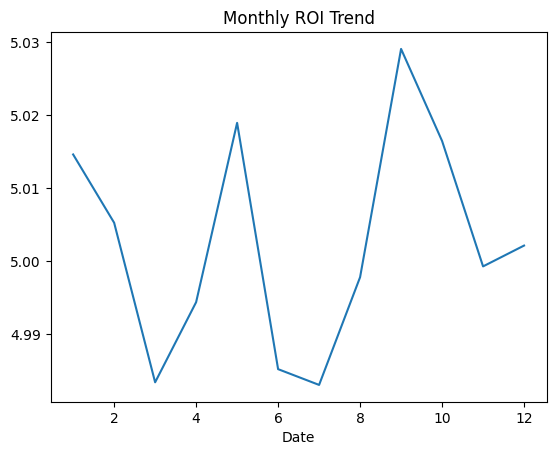

In [62]:
df.groupby(df['Date'].dt.month)['ROI'].mean().plot()
plt.title("Monthly ROI Trend")
plt.show()

##Insights
- Social Media shows the highest ROI, indicating better cost efficiency
- Discount Campaigns outperform other campaign types in terms of ROI
- Returning customers have higher conversion rates than new customers
- Higher acquisition cost does not guarantee higher ROI